In [1]:
import numpy as np
import time
import pandas as pd 
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [2]:
##TO ZOSTAJE, GIT
full_R = np.load("../data/c_a/processed/R_dataset_full.npz", allow_pickle=True)
X_full_R  = full_R["X"]
K0_full_R = full_R["K0"]

##3 values - new
full_R_477 = np.load("../data/c_a/processed/R_dataset_full_477.npz", allow_pickle=True)
X_full_R_477  = full_R_477["X"]
K0_full_R_477 = full_R_477["K0"]

##git
full_477 = np.load("../data/c_a/processed/dataset_full_k477.npz", allow_pickle=True)
X_full_477  = full_477["X"]
K0_full_477 = full_477["K0"]

In [3]:
X_full_477

array([[ 16336., 102831., 247964., ...,  13860.,   5166.,   3647.],
       [ 16337., 102974., 248526., ...,  13485.,   5202.,   3483.],
       [ 16380., 103075., 248500., ...,  12860.,   5332.,   3248.],
       ...,
       [ 16356., 102612., 246888., ...,  14160.,   4104.,   6200.],
       [ 16332., 102349., 246076., ...,  13187.,   4204.,   5804.],
       [ 16352., 102583., 246812., ...,  13907.,   4288.,   6710.]],
      shape=(278084, 31))

In [4]:
X_full_R

array([[1.63630e+04, 1.12176e+05, 1.16367e+00],
       [1.63810e+04, 1.11976e+05, 1.16367e+00],
       [1.63560e+04, 1.11724e+05, 1.16367e+00],
       ...,
       [1.63790e+04, 1.03272e+05, 1.20459e+00],
       [1.63550e+04, 1.02958e+05, 1.20459e+00],
       [1.63400e+04, 1.02878e+05, 1.20459e+00]], shape=(1551444, 3))

In [5]:
# N0 = X_full_R_477[:, 0]
# N4 = X_full_R_477[:, 1]
# N0_mean = np.mean(N0)
# N4_mean = np.mean(N4)
# print(N0_mean, N4_mean)

In [6]:
k0r = np.array(sorted(set(K0_full_R)), dtype=float)

k4r = []
for k in k0r:
    mask = (K0_full_R == k)
    
    # take first value (faster than mean)
    k4_val = X_full_R[mask][0, 2]
    k4r.append(k4_val)

k4r = np.array(k4r)

In [7]:
k4r

array([1.16367, 1.16813, 1.17117, 1.17267, 1.1742 , 1.17575, 1.17729,
       1.17887, 1.18042, 1.18198, 1.18514, 1.18675, 1.18841, 1.18992,
       1.19158, 1.19316, 1.19472, 1.1963 , 1.19964, 1.20459])

In [8]:
k0rk4r_base = pd.DataFrame({
    "k0": k0r,
    "k4": k4r
})

print(k0rk4r_base)

      k0       k4
0   4.67  1.16367
1   4.70  1.16813
2   4.72  1.17117
3   4.73  1.17267
4   4.74  1.17420
5   4.75  1.17575
6   4.76  1.17729
7   4.77  1.17887
8   4.78  1.18042
9   4.79  1.18198
10  4.81  1.18514
11  4.82  1.18675
12  4.83  1.18841
13  4.84  1.18992
14  4.85  1.19158
15  4.86  1.19316
16  4.87  1.19472
17  4.88  1.19630
18  4.90  1.19964
19  4.93  1.20459


In [9]:
k_dense = []
k4_dense = []


k_min = k0r.min()
k_max = k0r.max()

step = 0.001
k_uniform = np.round(np.arange(k_min, k_max + step, step), 5)


k_dense = np.unique(np.concatenate([k_uniform, k0r]))
k_dense = np.sort(k_dense)

k4_dense = np.interp(k_dense, k0r, k4r)


In [10]:
k0k4 = pd.DataFrame({
    "k0": k_dense,
    "k4": k4_dense
})

print(k0k4)

        k0        k4
0    4.670  1.163670
1    4.671  1.163819
2    4.672  1.163967
3    4.673  1.164116
4    4.674  1.164265
..     ...       ...
257  4.927  1.204095
258  4.928  1.204260
259  4.929  1.204425
260  4.930  1.204590
261  4.931  1.204590

[262 rows x 2 columns]


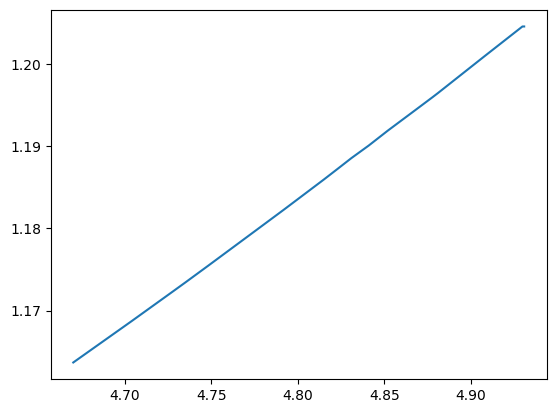

In [11]:
plt.plot(k_dense, k4_dense)
plt.show()

In [12]:
train = np.load("../data/c_a/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full = np.load("../data/c_a/processed/dataset_full.npz", allow_pickle=True)
X_full  = full["X"]
K0_full = full["K0"]

In [13]:
# mask = (K0_full == 4.77)
# X_masked = X_full[mask]
# X_full_477_minus1 = np.delete(X_full_477, 5, axis=1)
# print(np.allclose(X_masked, X_full_477_minus1))  # czy identyczne?
# print(len(X_masked), len(X_full_477[::100]))    

# print(X_masked[:4])
# print("####################")
# # print(X_full_477[:4].astype(int))

In [14]:
# def build_model(base_model, calibrated=False):
#     pipe = Pipeline([
#         # ("scaler", StandardScaler()),
#         ("clf", base_model)
#     ])
#     if not calibrated:
#         return pipe


# def run_supervised_pipeline(model, X_train, y_train, X_full):
#     model.fit(X_train, y_train)
#     train_score = model.score(X_train, y_train)

#     if hasattr(model, "predict_proba"):
#         print("pipipupu")
#         P_A = model.predict_proba(X_full)[:, 1]
#     else:
#         print("pupupipi")
#         scores = model.decision_function(X_full)
#         P_A = 1.0 / (1.0 + np.exp(-scores))

#     return train_score, P_A


In [15]:
k4771 = np.delete(X_full_477, 3, axis=1)
k4771

array([[ 16336., 102831., 247964., ...,  13860.,   5166.,   3647.],
       [ 16337., 102974., 248526., ...,  13485.,   5202.,   3483.],
       [ 16380., 103075., 248500., ...,  12860.,   5332.,   3248.],
       ...,
       [ 16356., 102612., 246888., ...,  14160.,   4104.,   6200.],
       [ 16332., 102349., 246076., ...,  13187.,   4204.,   5804.],
       [ 16352., 102583., 246812., ...,  13907.,   4288.,   6710.]],
      shape=(278084, 30))

In [16]:
# # =============================================================================
# # MAIN
# # =============================================================================



# models = {
#     "Logistic Regression": LogisticRegression(),
# }

# for name, base_model in models.items():
#     print(f"\n{'='*50}\nModel: {name}\n{'='*50}")

#     for calibrated in [False]:
#         label = "calibrated" if calibrated else "uncalibrated"
#         model = build_model(base_model, calibrated=calibrated)
#         k_target = 4.77
#         mask = (K0_full == k_target)
#         X_full_k477 = X_full[mask]
#         # k477 = np.delete(X_full_477, 5, axis=1)
#         # print(k477[::4])
#         k477 = X_full_k477[::100]
        
#         t0 = time.perf_counter()
#         train_score, P_A = run_supervised_pipeline(model, X_train, y_train, k477)
#         elapsed = time.perf_counter() - t0

        
       

In [17]:
# P_A

In [18]:
# plt.hist(P_A, bins=50)
# plt.title(f"{name} ({label}) - K0 = 4.77")
# plt.show()

In [20]:
k0_ref = 4.77
k4_ref = 1.178870

k477 = X_full_k477[::100]
n0 = k477[:, 0]
n4 = k477[:, 3]

med0 = np.median(n0)
med4 = np.median(n4)
def build_model(base_model, calibrated=False):
    pipe = Pipeline([("clf", base_model)])
    return pipe  # always return; extend here if calibrated=True logic is needed

def stat_reweighted_mean(P, w):
    return np.sum(P * w) / np.sum(w)

def stat_reweighted_susceptibility(P, w):
    mean = np.sum(P * w) / np.sum(w)
    if mean == 0:
        return 0.0
    var = np.sum(w * (P - mean)**2) / np.sum(w)
    return var / mean

def block_jackknife_reweighted(P, w, stat_func, B):
    n = len(P)
    m = n // B
    if m < 2:
        return None
    P = P[:m * B]
    w = w[:m * B]
    P_blocks = P.reshape(B, m)
    w_blocks = w.reshape(B, m)
    theta_hat = stat_func(P, w)
    thetas = np.array([
        stat_func(
            np.concatenate([P_blocks[:i], P_blocks[i+1:]]).ravel(),
            np.concatenate([w_blocks[:i], w_blocks[i+1:]]).ravel()
        )
        for i in range(B)
    ])
    theta_bar = np.mean(thetas)
    bias = (B - 1) * (theta_bar - theta_hat)
    theta_jack = theta_hat - bias
    var_dats = np.var(thetas, ddof=1)
    mse = var_dats * (B - 1)**2 / B
    se = np.sqrt(mse)
    return theta_hat, theta_jack, se

# =============================================================================
# REWEIGHTING + JACKKNIFE
# =============================================================================
reweightedP = []
reweightedChi = []

for k0, k4 in zip(k_dense, k4_dense):
    wght = np.exp(
        (k0 - k0_ref) * (n0 - med0)
        - (k4 - k4_ref) * (n4 - med4)
    )
    wght = wght / np.mean(wght)

    # --- MEAN: pick B that gives the most conservative (largest) SE ---
    best_mean_se = -np.inf
    best_mean = None
    for B in range(6, 61):
        out = block_jackknife_reweighted(P_A, wght, stat_reweighted_mean, B)
        if out is None:
            continue
        _, theta_jack, se = out
        if se > best_mean_se:
            best_mean_se = se
            best_mean = theta_jack

    # --- SUSCEPTIBILITY ---
    best_chi_se = -np.inf
    best_chi = None
    for B in range(6, 61):
        out = block_jackknife_reweighted(P_A, wght, stat_reweighted_susceptibility, B)
        if out is None:
            continue
        _, theta_jack, se = out
        if se > best_chi_se:
            best_chi_se = se
            best_chi = theta_jack

    reweightedP.append([k0, best_mean, best_mean_se])
    reweightedChi.append([k0, best_chi, best_chi_se])

NameError: name 'X_full_k477' is not defined

In [ ]:

# weights = np.exp(
#     (k_target - k0_ref) * (N0 - N0_mean)
#     - (k4_target - k4_ref) * (N4 - N4_mean)
# )

In [ ]:
# P_reweighted = np.sum(P_A * weights) / np.sum(weights)
# print(P_reweighted)

In [ ]:
# k0_ref = 4.77
# P_reweighted = np.sum(P_A * weights) / np.sum(weights)

In [ ]:



# reweightedP = []

# for k0, k4 in zip(k_dense, k4_dense):

#     wght = np.exp((k0 - k0_ref) * (n0 - med0)
#         - (k4 - k4_ref) * (n4 - med4)
#     )
    
#     mean_P = np.sum(P_A * wght) / np.sum(wght)

#     reweightedP.append([k0, mean_P])

# reweightedP = np.array(reweightedP)

In [ ]:
# from scipy.interpolate import interp1d

# # create smooth inverse function: P → k0
# f_inv = interp1d(reweightedP[:,1], reweightedP[:,0], kind='linear')

# k0_half = f_inv(0.5)

# print(k0_half)

In [ ]:
# plt.plot(reweightedP[:,0], reweightedP[:,1])
# plt.title("reweightedP")
# plt.ylim(bottom=0, top=1.0) 
# plt.show()

In [ ]:
# def stat_reweighted_mean(P, w):

#     return np.sum(P * w) / np.sum(w)


# def stat_reweighted_susceptibility(P, w):

#     mean = np.sum(P * w) / np.sum(w)

#     var = np.sum(w * (P - mean)**2) / np.sum(w)

#     return var / mean

In [ ]:
# def block_jackknife_reweighted(P, w, stat_func, B):

#     n = len(P)

#     m = n // B

#     if m < 2:
#         return None

#     # truncate
#     P = P[:m * B]
#     w = w[:m * B]

#     P_blocks = P.reshape(B, m)
#     w_blocks = w.reshape(B, m)

#     # full estimator
#     theta_hat = stat_func(P, w)

#     # leave-one-block-out
#     thetas = np.array([

#         stat_func(

#             np.concatenate([
#                 P_blocks[:i],
#                 P_blocks[i+1:]
#             ]).ravel(),

#             np.concatenate([
#                 w_blocks[:i],
#                 w_blocks[i+1:]
#             ]).ravel()

#         )

#         for i in range(B)

#     ])

#     theta_bar = np.mean(thetas)

#     # bias correction
#     bias = (B - 1) * (theta_bar - theta_hat)

#     theta_jack = theta_hat - bias

#     var_dats = np.var(thetas, ddof=1)

#     mse = var_dats * (B - 1)**2 / B

#     se = np.sqrt(mse)

#     return theta_hat, theta_jack, se

In [ ]:
# # =============================================================================
# # REWEIGHTING + JACKKNIFE
# # =============================================================================

# reweightedP = []

# reweightedChi = []

# for k0, k4 in zip(k_dense, k4_dense):

#     # -------------------------------------------------------------------------
#     # WEIGHTS
#     # -------------------------------------------------------------------------

#     wght = np.exp(

#         (k0 - k0_ref) * (n0 - med0)

#         -

#         (k4 - k4_ref) * (n4 - med4)

#     )

#     # optional normalization
#     wght = wght / np.mean(wght)

#     # -------------------------------------------------------------------------
#     # MEAN JACKKNIFE
#     # -------------------------------------------------------------------------

#     se_vals = []
#     theta_vals = []
    
#     for B in range(5, 40):
    
#         out = block_jackknife_reweighted(
#             P_A,
#             wght,
#             stat_reweighted_mean,
#             B
#         )
    
#         if out is None:
#             continue
    
#         _, theta_jack, se = out
    
#         se_vals.append(se)
#         theta_vals.append(theta_jack)
    
#     se_vals = np.array(se_vals)
#     theta_vals = np.array(theta_vals)

#     # conservative but stable
#     best_mean_se = np.percentile(se_vals, 75)

# # corresponding theta
# idx = np.argmin(np.abs(se_vals - best_mean_se))

# best_mean = theta_vals[idx]
    
#     best_mean_se = -np.inf
#     best_mean = None

#     for B in range(6, 61):

#         out = block_jackknife_reweighted(
#             P_A,
#             wght,
#             stat_reweighted_mean,
#             B
#         )

#         if out is None:
#             continue

#         _, theta_jack, se = out

#         if se > best_mean_se:

#             best_mean_se = se
#             best_mean = theta_jack

#     # -------------------------------------------------------------------------
#     # SUSCEPTIBILITY JACKKNIFE
#     # -------------------------------------------------------------------------

#     best_chi_se = -np.inf
#     best_chi = None

#     for B in range(6, 61):

#         out = block_jackknife_reweighted(
#             P_A,
#             wght,
#             stat_reweighted_susceptibility,
#             B
#         )

#         if out is None:
#             continue

#         _, theta_jack, se = out

#         if se > best_chi_se:

#             best_chi_se = se
#             best_chi = theta_jack

#     # -------------------------------------------------------------------------
#     # STORE
#     # -------------------------------------------------------------------------

#     reweightedP.append([
#         k0,
#         best_mean,
#         best_mean_se
#     ])

#     reweightedChi.append([
#         k0,
#         best_chi,
#         best_chi_se
#     ])

In [ ]:
# # =============================================================================
# # ARRAYS
# # =============================================================================

# reweightedP = np.array(reweightedP)

# reweightedChi = np.array(reweightedChi)

# # =============================================================================
# # PLOTTING
# # =============================================================================

In [ ]:
# plt.figure(figsize=(8,6))

# plt.title("Reweighted Mean Probability")

# plt.plot(
#     reweightedP[:,0],
#     reweightedP[:,1]
# )

# plt.fill_between(
#     reweightedP[:,0],
#     reweightedP[:,1] - reweightedP[:,2],
#     reweightedP[:,1] + reweightedP[:,2],
#     alpha=0.4,
#     color="red"
# )

# plt.xlabel("k0")

# plt.ylabel("Mean P(A)")

# # =============================================================================
# # CHI
# # =============================================================================

# plt.figure(figsize=(8,6))

# plt.title("Reweighted Susceptibility")

# plt.plot(
#     reweightedChi[:,0],
#     reweightedChi[:,1]
# )

# plt.fill_between(
#     reweightedChi[:,0],
#     reweightedChi[:,1] - reweightedChi[:,2],
#     reweightedChi[:,1] + reweightedChi[:,2],
#     alpha=0.4,
#     color="red"
# )

# plt.xlabel("k0")

# plt.ylabel("Chi")

# plt.show()